In [15]:
import ansys.rocky.core as pyrocky
import matplotlib.pyplot as plt
import numpy as np

In [16]:
rocky = pyrocky.launch_rocky('/home/rocky-vm/ansys_inc/v242/rocky/Rocky')
project = rocky.api.OpenProject("/home/rocky-vm/Documents/compression/uniaxcompr.rocky")
study = project.GetStudy()
particles = study.GetParticles()

particles.GetClassName()

Looking for libstdc++ ...
System:
 - version: 3.4.30
 - path: /lib/x86_64-linux-gnu/libstdc++.so.6

Bundled:
 - version: 3.4.30
 - path: /home/rocky-vm/ansys_inc/v242/rocky/bin/gcc-libs/libstdc++.so.6

Choosing bundled libstdc++
Choosing system libstdc++
json:{"status": "SIMULATING"}


QSocketNotifier: Can only be used with threads started with QThread


json:{"status": "SIMULATING", "message": "uniaxcompr.rocky"}


'ParticleMeshProcessSubject'

In [17]:
particles.GetGridFunctionNames()

['Orientation : Angle',
 'Particle Group',
 'Coordinate : Z',
 'Velocity : Rotational : Y',
 'Orientation : Vector : X',
 'Particle Equivalent Diameter',
 'Coordinate : X',
 'Particle Shape',
 'Particle Material',
 'Particle Inlet',
 'Velocity : Translational : X',
 'Orientation : Vector : Y',
 'Coordinate : Y',
 'Particle Size',
 'Particle Volume',
 'Residence Time',
 'Particle Mass',
 'Velocity : Translational : Z',
 'Particle ID',
 'System Released Time',
 'Particle Boundary',
 'Velocity : Rotational : Z',
 'Velocity : Rotational : X',
 'Velocity : Translational : Absolute',
 'Particle Type',
 'Particle Surface Area',
 'Orientation : Vector : Z',
 'Velocity : Rotational : Absolute',
 'Velocity : Translational : Y']

In [18]:
x = particles.GetGridFunction('Coordinate : X')
x_arr_init = x.GetArray(time_step=1)
x_max_init, x_min_init = x_arr_init.min().item(), x_arr_init.max().item()

x_arr_compr = x.GetArray(time_step=-1)
x_max_compr, x_min_compr = x_arr_compr.min().item(), x_arr_compr.max().item()

y = particles.GetGridFunction('Coordinate : Y')
y_arr_init = y.GetArray(time_step=1)
y_max_init, y_min_init = y_arr_init.min().item(), y_arr_init.max().item()

y_arr_compr = y.GetArray(time_step=-1)
y_max_compr, y_min_compr = y_arr_compr.min().item(), y_arr_compr.max().item()

z = particles.GetGridFunction('Coordinate : Z')
z_arr_init = z.GetArray(time_step=1)
z_max_init, z_min_init = z_arr_init.min().item(), z_arr_init.max().item()

z_arr_compr = z.GetArray(time_step=-1)
z_max_compr, z_min_compr = z_arr_compr.min().item(), z_arr_compr.max().item()

json:{"status": "SIMULATING", "message": "uniaxcompr.rocky *"}


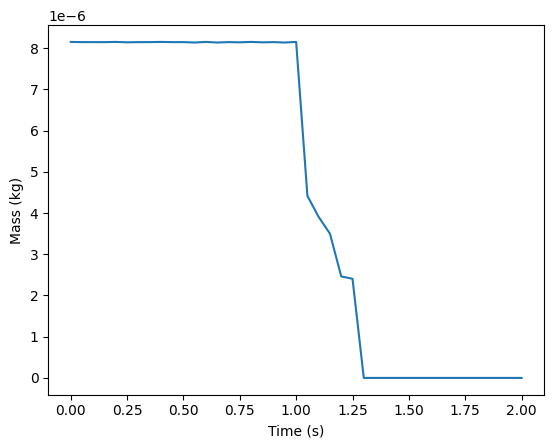

In [19]:
processes = project.GetUserProcessCollection()

cuboid_selection_init = processes.CreateCubeProcess(particles)

cuboid_selection_init.SetSize(
    x_max_init-x_min_init,
    y_max_init-y_min_init,
    z_max_init-z_min_init,
    unit="m"
)

cuboid_selection_init.SetCenter(
    (x_max_init+x_min_init)/2,
    (y_max_init+y_min_init)/2,
    (z_max_init+z_min_init)/2,
    unit="m"
)

# cuboid_selection_init.GetCurveNames()
t, mass_init = cuboid_selection_init.GetNumpyCurve('Particles Mass')
plt.plot(t,mass_init)
plt.ylabel("Mass (kg)")
plt.xlabel("Time (s)");

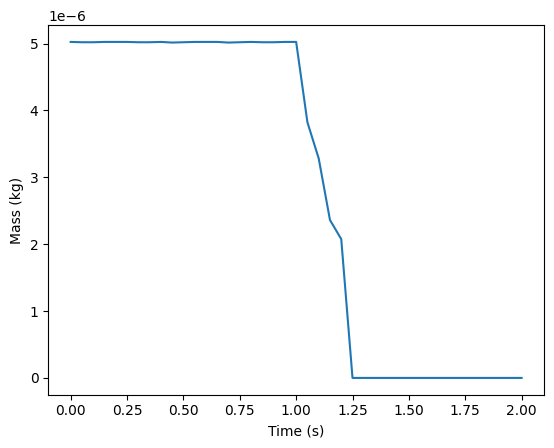

In [20]:
cuboid_selection_compr = processes.CreateCubeProcess(particles)

cuboid_selection_compr.SetSize(
    x_max_compr-x_min_compr,
    y_max_compr-y_min_compr,
    z_max_compr-z_min_compr,
    unit="m"
)

cuboid_selection_init.SetCenter(
    (x_max_compr+x_min_compr)/2,
    (y_max_compr+y_min_compr)/2,
    (z_max_compr+z_min_compr)/2,
    unit="m"
)

# cuboid_selection_init.GetCurveNames()
t, mass_compr = cuboid_selection_compr.GetNumpyCurve('Particles Mass')
plt.plot(t,mass_compr)
plt.ylabel("Mass (kg)")
plt.xlabel("Time (s)");

In [21]:
V_bulk = (x_max_init-x_min_init)*(y_max_init-y_min_init)*(z_max_init-z_min_init)
bulk_dens = np.abs(mass_init.max()/V_bulk).item()
bulk_dens

1763.3140697747042

In [22]:
V_packed = (x_max_compr-x_min_compr)*(y_max_compr-y_min_compr)*(z_max_compr-z_min_compr)
packed_dens = np.abs(mass_compr.max()/V_bulk).item()

packed_dens

1087.1017069512598

In [23]:
hausner_ratio = bulk_dens/packed_dens
print("Hausner Ratio: ", hausner_ratio)
compr_indx = 100 * (1-packed_dens/bulk_dens)
print("Compressibility Index: ",compr_indx)

Hausner Ratio:  1.6220322886989658
Compressibility Index:  38.348946135831774


In [24]:
rocky.close()

Traceback (most recent call last):
  File "/home/staff/4fbuuser/ado_agent/_work/8/s/etk/plugins10/source/python/plugins10/plugins/scripting/base_scripting.py", line 97, in ExecScripting
  File "/home/staff/4fbuuser/ado_agent/_work/8/s/rocky/rocky30/source/python/rocky30/plugins/project/project_manager.py", line 430, in ActualClose
  File "/home/staff/4fbuuser/ado_agent/_work/8/s/kraken20/source/python/kraken20/plugins/project_manager/_project_manager.py", line 18, in ActualClose
  File "/home/staff/4fbuuser/ado_agent/_work/8/s/etk/petroapp10/source/python/petroapp10/plugins/project_handler/_project_manager.py", line 23, in ActualClose
  File "/home/staff/4fbuuser/ado_agent/_work/8/s/etk/plugins10/source/python/plugins10/plugins/project_manager/_project_manager.py", line 223, in Close
  File "/home/staff/4fbuuser/ado_agent/_work/8/s/etk/plugins10/source/python/plugins10/plugins/project_manager/_project_manager.py", line 769, in SaveIfNeeded
RuntimeError: Unexpected condition: None. Shou